In [123]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mallem000jashwanth/dataset/diabetes_prediction_dataset.csv


### **Environment Setup & Library Imports**

In [124]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries imported successfully!")

All libraries imported successfully!


In [125]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [126]:
file_path = "/kaggle/input/datasets/mallem000jashwanth/dataset/diabetes_prediction_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("\nShape of dataset:", df.shape)
df.head()

Dataset loaded successfully!

Shape of dataset: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [127]:
print("Columns:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nClass Distribution:\n")
print(df["diabetes"].value_counts())

Columns:
 Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Data Types:

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing Values:

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Class Distribution:

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [128]:

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 8)
Target shape: (100000,)


In [129]:

df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'])

X = df_encoded.drop("diabetes", axis=1)
y = df_encoded["diabetes"]

print("Encoding complete. New features:", X.columns.tolist())

Encoding complete. New features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


### **Data Splitting and Stratification**

In [130]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (80000, 15)
Test shape: (20000, 15)

Train class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Test class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [131]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully. All values are between 0 and 1.")

Scaling completed successfully. All values are between 0 and 1.


In [132]:
print(X_train_scaled[:2])
print(X_test_scaled[:2])

[[1.         1.         0.         0.20203081 0.54545455 0.29545455
  1.         0.         0.         0.         0.         0.
  1.         0.         0.        ]
 [0.23673674 0.         0.         0.17705415 0.18181818 0.20909091
  1.         0.         0.         0.         0.         0.
  0.         1.         0.        ]]
[[0.44944945 0.         0.         0.14740896 0.45454545 0.36363636
  1.         0.         0.         0.         0.         0.
  1.         0.         0.        ]
 [0.38688689 0.         0.         0.20203081 0.41818182 0.20909091
  1.         0.         0.         0.         0.         0.
  0.         1.         0.        ]]


### **Logistic Regression**

In [133]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)


y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_prob_log)

print("=== Logistic Regression Results ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression Results ===
Accuracy  : 0.9600
Precision : 0.8594
Recall    : 0.6329
F1 Score  : 0.7290
AUC Score : 0.9625

Confusion Matrix:
[[18124   176]
 [  624  1076]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



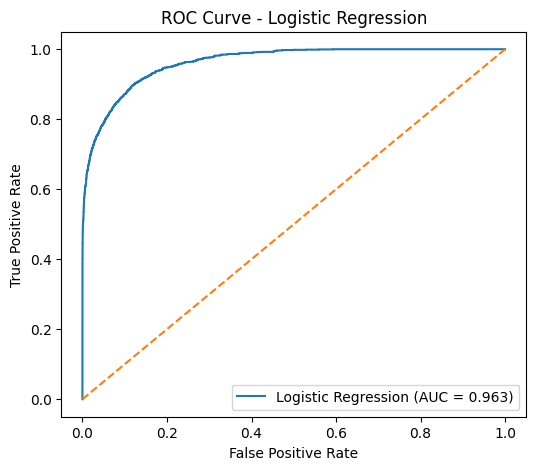

In [134]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### **Decision Tree**

In [135]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None  # let it grow fully for now
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]


accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("=== Decision Tree Results ===")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"AUC Score : {auc_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

=== Decision Tree Results ===
Accuracy  : 0.9509
Precision : 0.7010
Recall    : 0.7376
F1 Score  : 0.7188
AUC Score : 0.8549

Confusion Matrix:
[[17765   535]
 [  446  1254]]


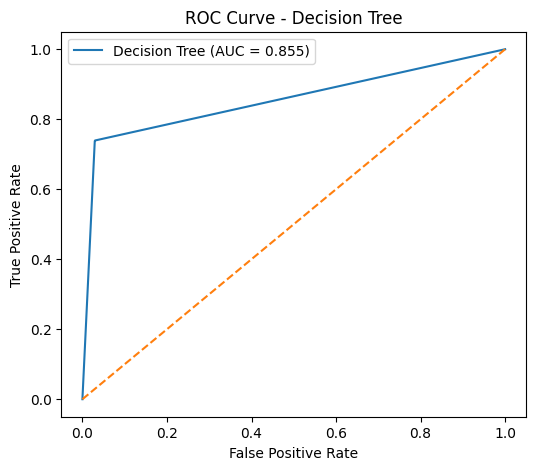

In [136]:


fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

### **Random Forest**

In [137]:


from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf_model.fit(X_train_scaled, y_train)


y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest Results ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"AUC Score : {auc_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy  : 0.9701
Precision : 0.9429
Recall    : 0.6900
F1 Score  : 0.7969
AUC Score : 0.9605

Confusion Matrix:
[[18229    71]
 [  527  1173]]


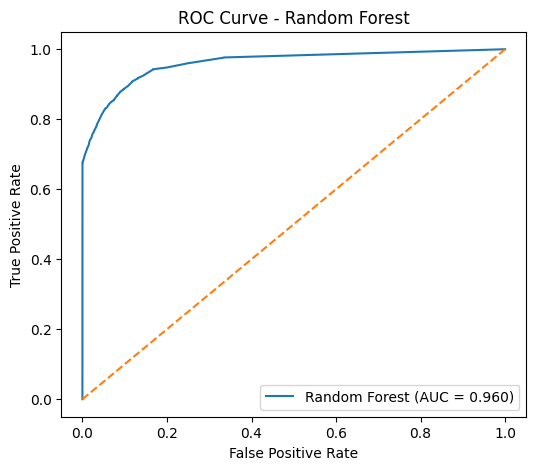

In [138]:


fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### **Gradient Boosting**

In [139]:

from sklearn.ensemble import GradientBoostingClassifier


gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


gb_model.fit(X_train_scaled, y_train)


y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]


accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("=== Gradient Boosting Results ===")
print(f"Accuracy  : {accuracy_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1 Score  : {f1_gb:.4f}")
print(f"AUC Score : {auc_gb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

=== Gradient Boosting Results ===
Accuracy  : 0.9723
Precision : 0.9783
Recall    : 0.6894
F1 Score  : 0.8088
AUC Score : 0.9794

Confusion Matrix:
[[18274    26]
 [  528  1172]]


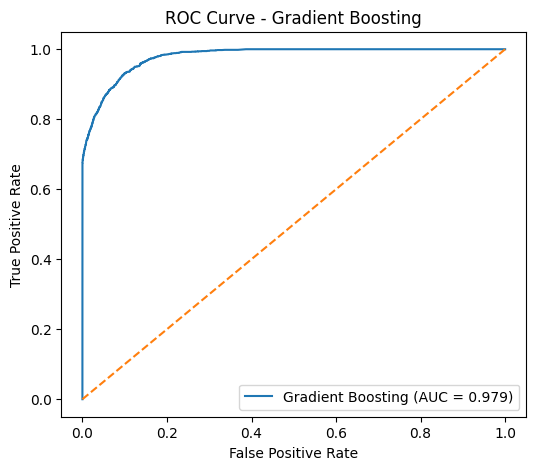

In [140]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

### **K-Nearest Neighbors**

In [141]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("=== KNN Results ===")
print(f"Accuracy  : {accuracy_knn:.4f}")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1 Score  : {f1_knn:.4f}")
print(f"AUC Score : {auc_knn:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

=== KNN Results ===
Accuracy  : 0.9614
Precision : 0.8925
Recall    : 0.6200
F1 Score  : 0.7317
AUC Score : 0.9027

Confusion Matrix:
[[18173   127]
 [  646  1054]]


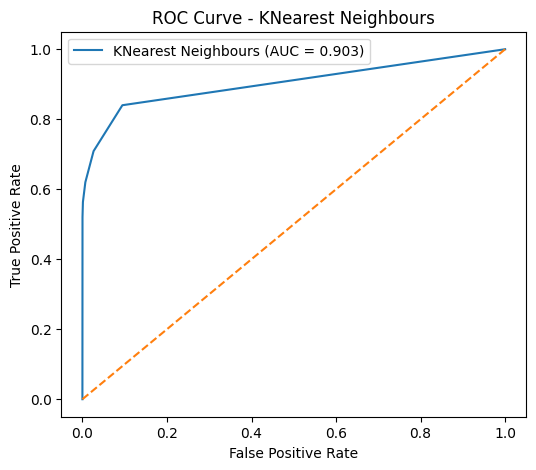

In [142]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr_knn, tpr_knn, label=f"KNearest Neighbours (AUC = {auc_knn:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNearest Neighbours")
plt.legend()
plt.show()

### **Support Vector Machine**

In [143]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


svm_base = LinearSVC(random_state=42)
svm_model = CalibratedClassifierCV(svm_base)


svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("=== SVM Results ===")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1 Score  : {f1_svm:.4f}")
print(f"AUC Score : {auc_svm:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== SVM Results ===
Accuracy  : 0.9603
Precision : 0.8577
Recall    : 0.6382
F1 Score  : 0.7319
AUC Score : 0.9618

Confusion Matrix:
[[18120   180]
 [  615  1085]]


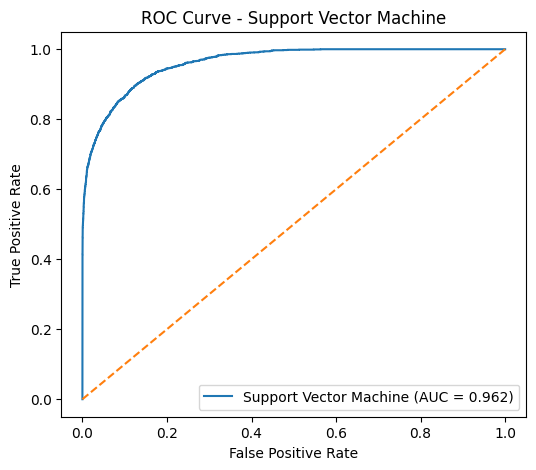

In [144]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Support Vector Machine")
plt.legend()
plt.show()

### **MARS**

In [145]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression


spline_mars_model = make_pipeline(
    SplineTransformer(n_knots=5, degree=1, include_bias=False),
    LogisticRegression(max_iter=1000)
)

print("Training Piecewise Linear (Spline) model...")
spline_mars_model.fit(X_train_scaled, y_train)


y_pred_mars = spline_mars_model.predict(X_test_scaled)
y_prob_mars = spline_mars_model.predict_proba(X_test_scaled)[:, 1]


accuracy_mars = accuracy_score(y_test, y_pred_mars)
precision_mars = precision_score(y_test, y_pred_mars)
recall_mars = recall_score(y_test, y_pred_mars)
f1_mars = f1_score(y_test, y_pred_mars)
auc_mars = roc_auc_score(y_test, y_prob_mars)

print("=== Piecewise Linear (MARS-like) Results ===")
print(f"Accuracy  : {accuracy_mars:.4f}")
print(f"Precision : {precision_mars:.4f}")
print(f"Recall    : {recall_mars:.4f}")
print(f"F1 Score  : {f1_mars:.4f}")
print(f"AUC Score : {auc_mars:.4f}")

Training Piecewise Linear (Spline) model...
=== Piecewise Linear (MARS-like) Results ===
Accuracy  : 0.9677
Precision : 0.9320
Recall    : 0.6688
F1 Score  : 0.7788
AUC Score : 0.9708


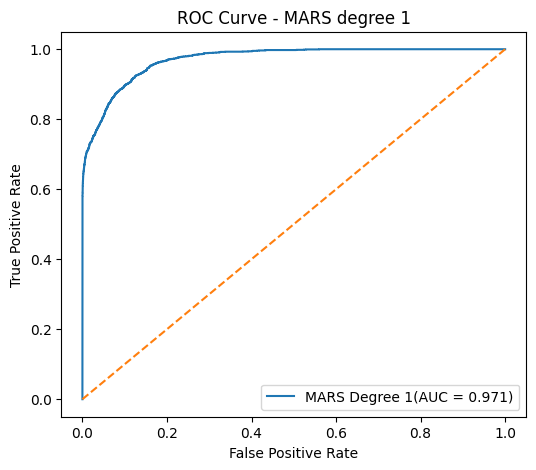

In [146]:
fpr_mars, tpr_mars, thresholds_mars = roc_curve(y_test, y_prob_mars)

plt.figure(figsize=(6,5))
plt.plot(fpr_mars, tpr_mars, label=f"MARS Degree 1(AUC = {auc_mars:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MARS degree 1")
plt.legend()
plt.show()

### **Comparative Performance Analysis**

In [147]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting","KNeighborsClassifier","LinearSVC","MARS"],
    "Accuracy": [accuracy, accuracy_dt, accuracy_rf, accuracy_gb,accuracy_knn,accuracy_svm,accuracy_mars],
    "Precision": [precision, precision_dt, precision_rf, precision_gb,precision_knn,precision_svm,precision_mars],
    "Recall": [recall, recall_dt, recall_rf, recall_gb,recall_knn,recall_svm,recall_mars],
    "F1 Score": [f1, f1_dt, f1_rf, f1_gb,f1_knn,f1_svm,f1_mars],
    "AUC": [auc, auc_dt, auc_rf, auc_gb,auc_knn,auc_svm,auc_mars]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.96000,0.859425,0.632941,0.728997,0.962518
1,Decision Tree,0.95095,0.700950,0.737647,0.718831,0.854891
2,Random Forest,0.97010,0.942926,0.690000,0.796875,0.960478
3,Gradient Boosting,0.97230,0.978297,0.689412,0.808834,0.979408
4,KNeighborsClassifier,0.96135,0.892464,0.620000,0.731690,0.902708
5,LinearSVC,0.96025,0.857708,0.638235,0.731872,0.961822
6,MARS,0.96770,0.931967,0.668824,0.778767,0.970842


### **Visualizing Model Performance: ROC Curve Comparison**

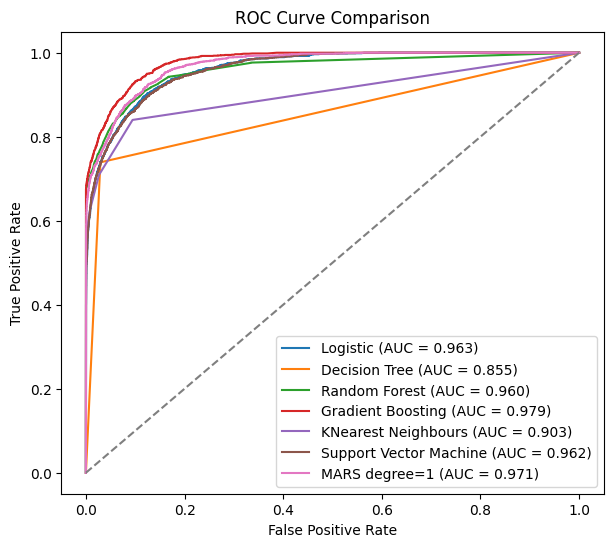

In [190]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNearest Neighbours (AUC = {auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot(fpr_mars, tpr_mars,label=f"MARS degree=1 (AUC = {auc_mars:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### **Model Interpretability with SHAP (SHapley Additive exPlanations)**

In [149]:


import shap


X_shap_sample = X_test_scaled[:100]


explainer = shap.TreeExplainer(gb_model)


shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values computed successfully!")

SHAP values computed successfully!


### **Model Performance Visualization**

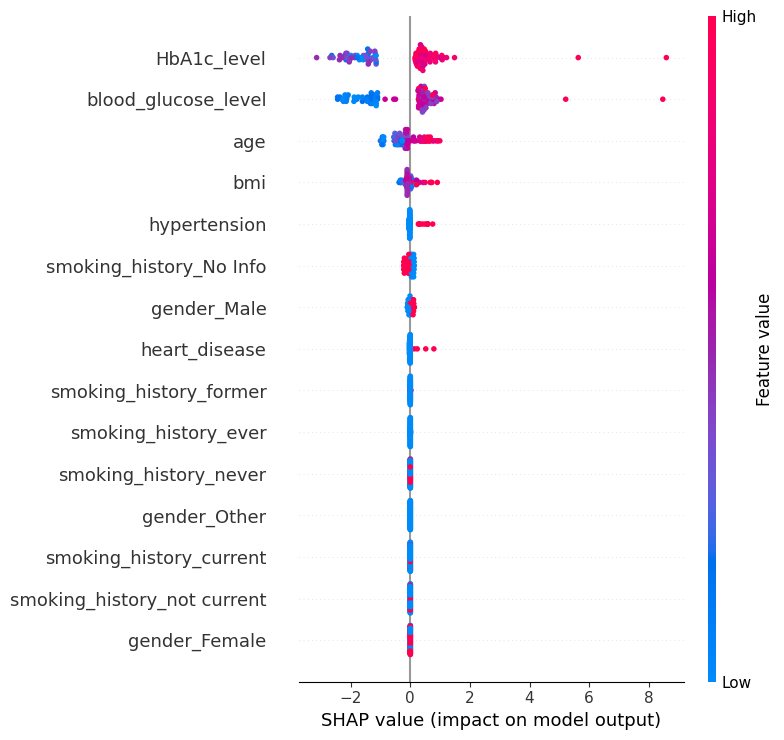

In [150]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns
)

In [151]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 15)


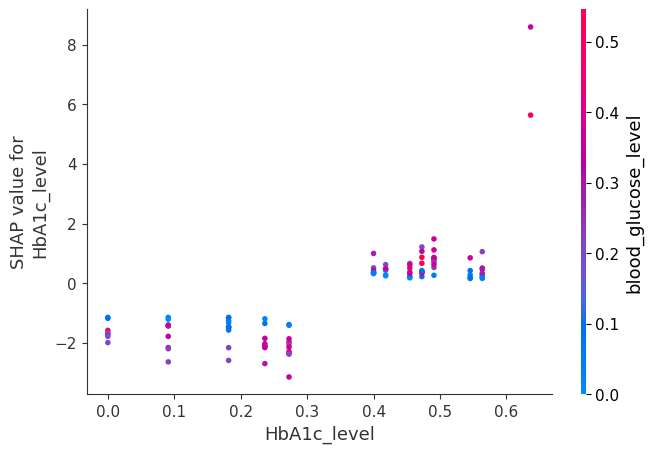

In [152]:
shap.dependence_plot(
    "HbA1c_level", 
    shap_values, 
    X_shap_sample, 
    feature_names=X.columns
)

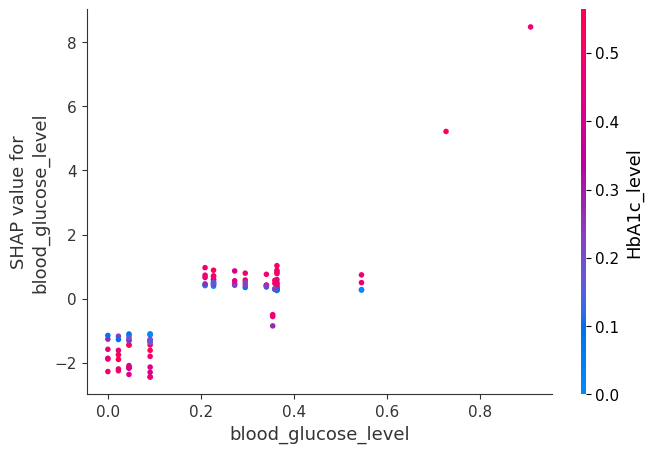

In [153]:
shap.dependence_plot(
    "blood_glucose_level",
    shap_values,   
    X_shap_sample,
    feature_names=X.columns
)

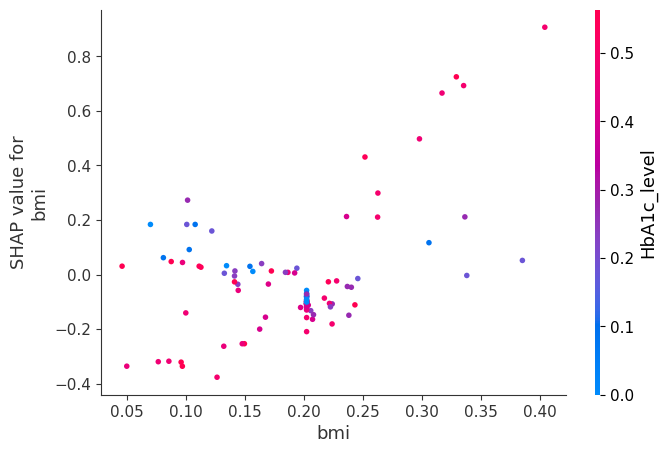

In [154]:
shap.dependence_plot(
    "bmi",
    shap_values,   
    X_shap_sample,
    feature_names=X.columns
)

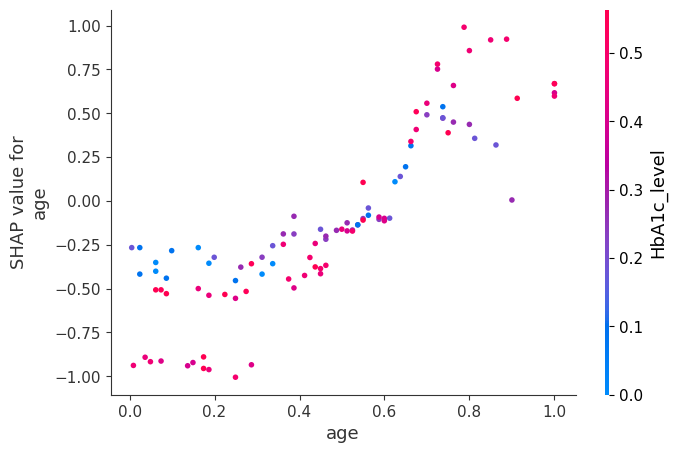

In [155]:
shap.dependence_plot("age", shap_values, X_shap_sample, feature_names=X.columns)

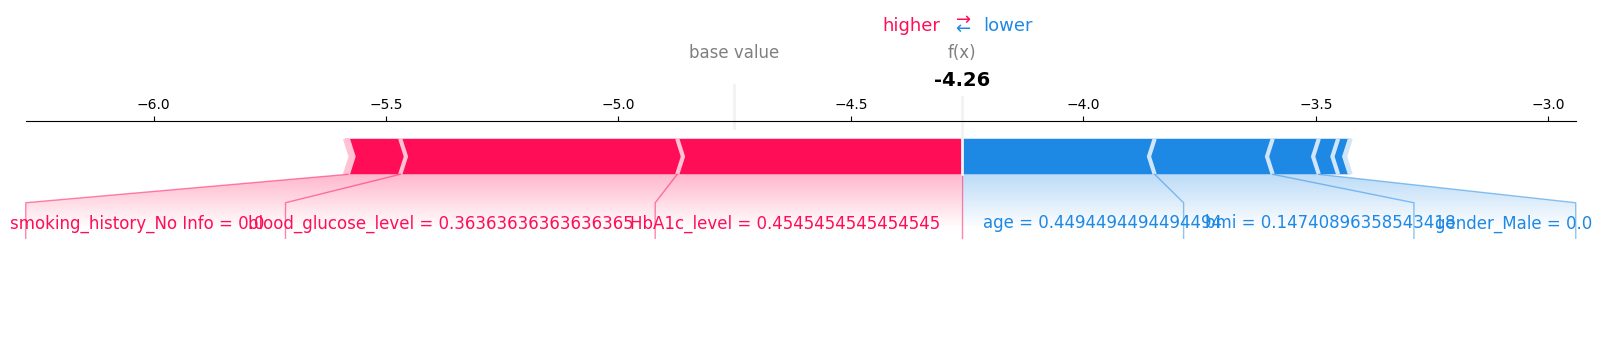

In [156]:
shap.force_plot(
    explainer.expected_value,     
    shap_values[0],                
    X_shap_sample[0],
    feature_names=X.columns,
    matplotlib=True
)

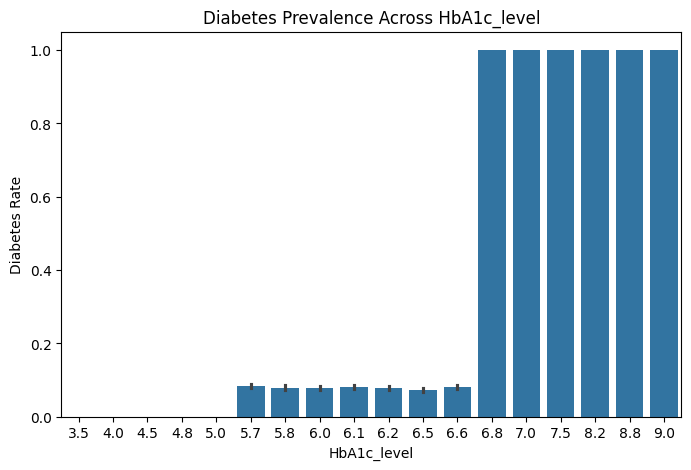

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=df["HbA1c_level"], y=df["diabetes"])
plt.title("Diabetes Prevalence Across HbA1c_level")
plt.ylabel("Diabetes Rate")
plt.xlabel("HbA1c_level")
plt.show()

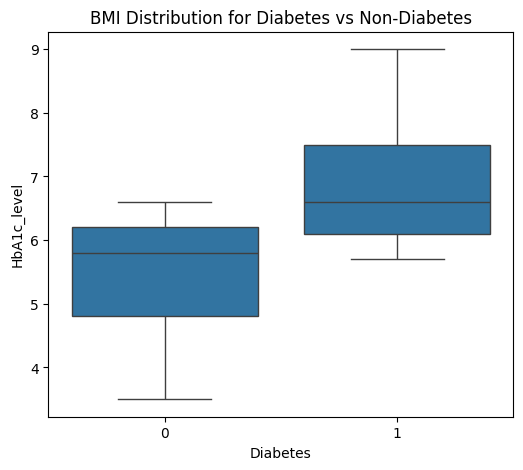

In [158]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df["diabetes"], y=df["HbA1c_level"])
plt.title("BMI Distribution for Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c_level")
plt.show()

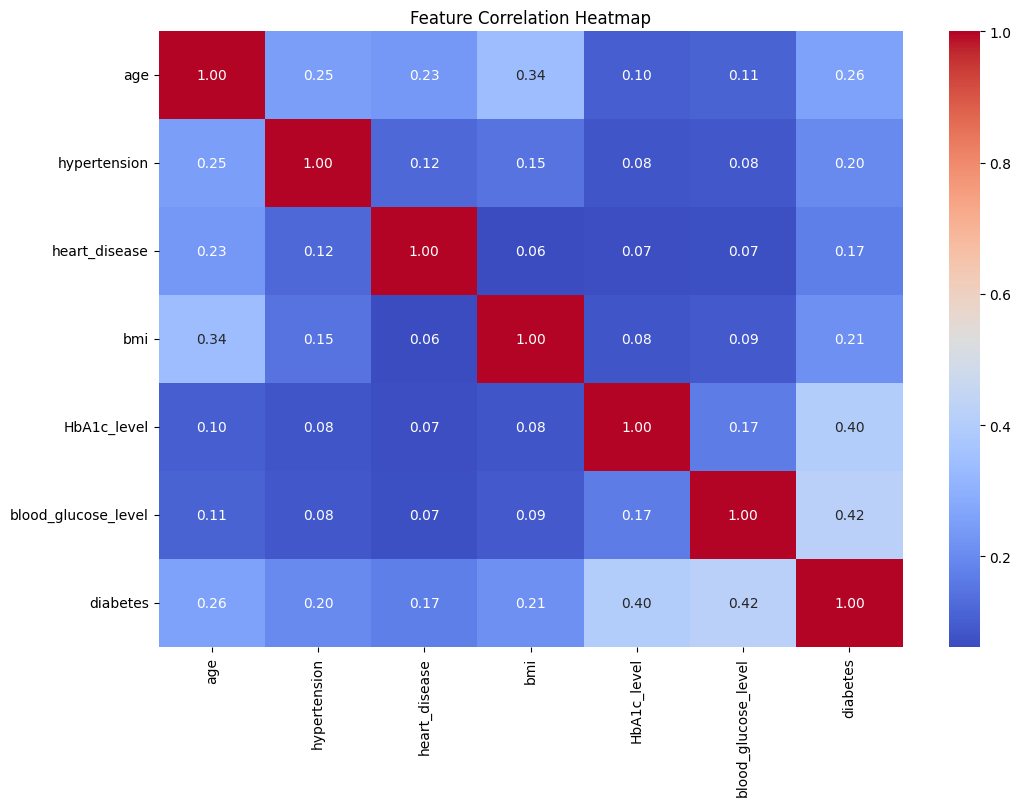

In [159]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

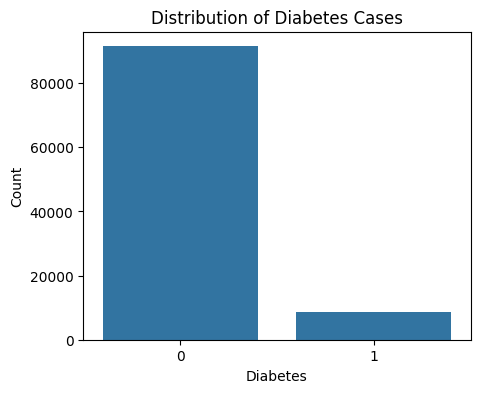

In [160]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["diabetes"])
plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

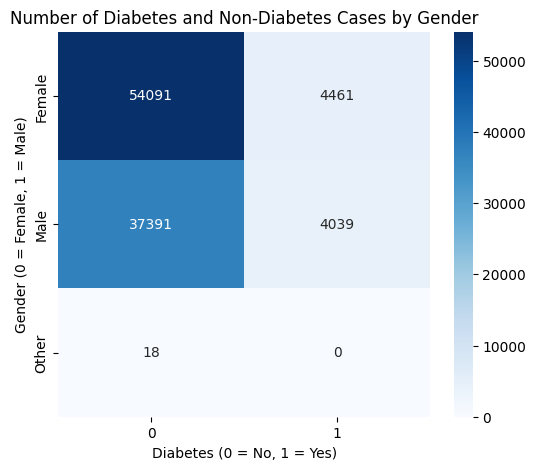

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

gender_diabetes = pd.crosstab(df['gender'], df['diabetes'])

plt.figure(figsize=(6,5))
sns.heatmap(gender_diabetes, annot=True, fmt='d', cmap='Blues')

plt.title("Number of Diabetes and Non-Diabetes Cases by Gender")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Gender (0 = Female, 1 = Male)")
plt.show()

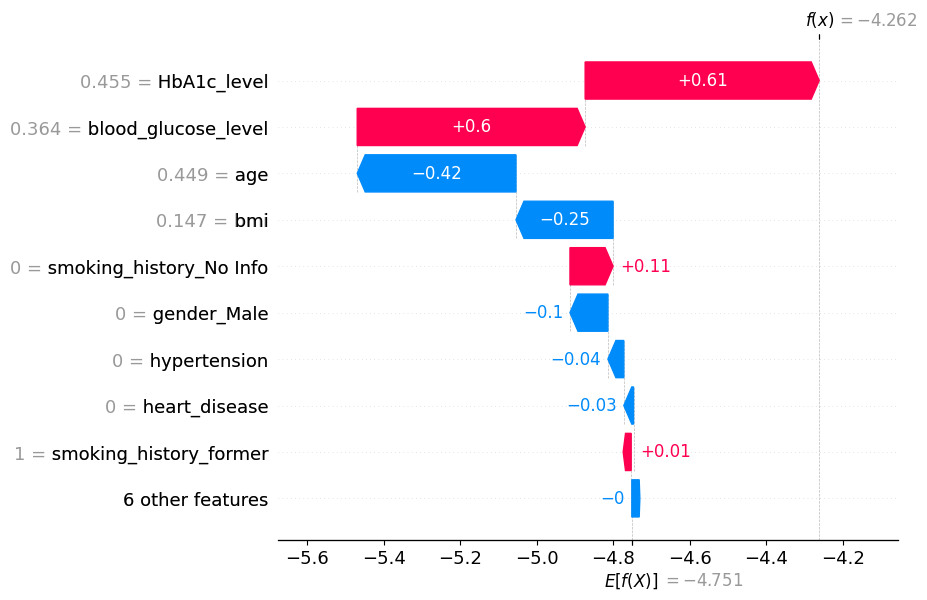

In [162]:
import pandas as pd

X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],                 
        base_values=explainer.expected_value,  
        data=X_shap_sample_df.iloc[0],
        feature_names=X.columns
    )
)

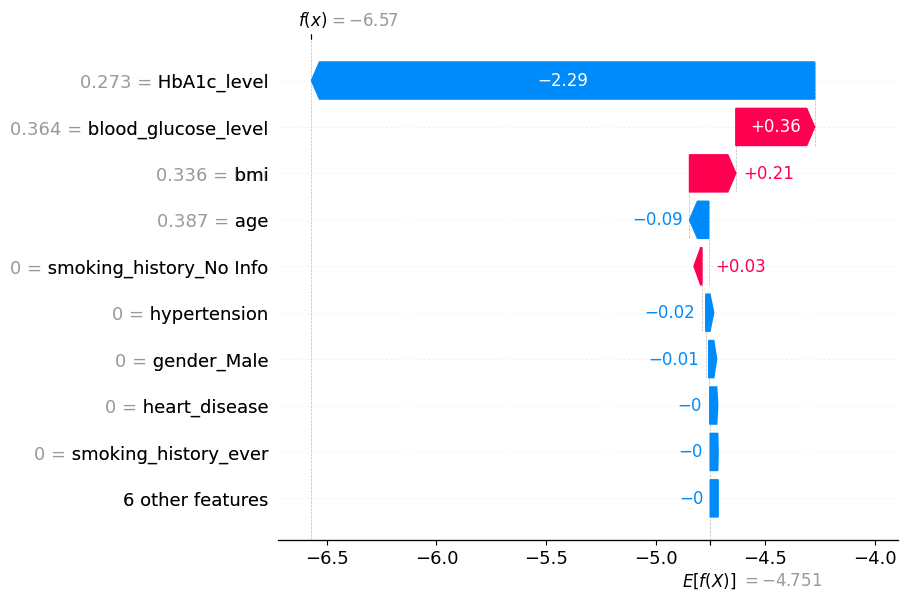

In [163]:
import pandas as pd

X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10],              
        base_values=explainer.expected_value, 
        data=X_shap_sample_df.iloc[10],          
        feature_names=X.columns
    )
)

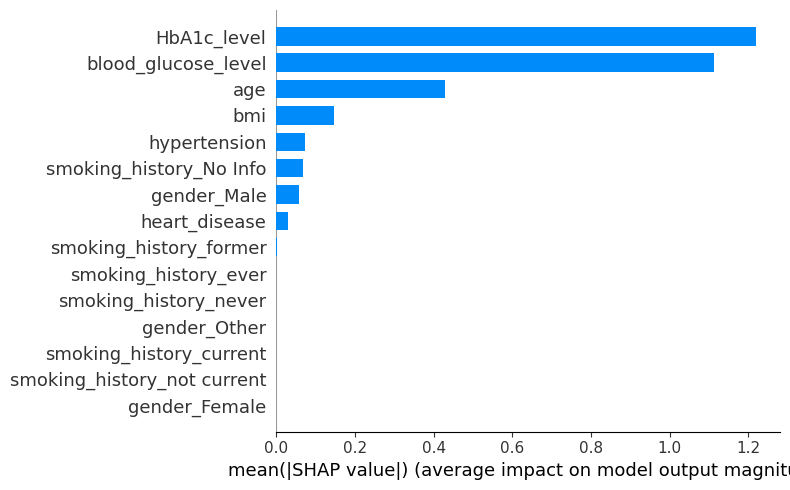

In [185]:

shap.summary_plot(
    shap_values, 
    X_shap_sample,
    plot_type="bar",
    feature_names=X.columns
)

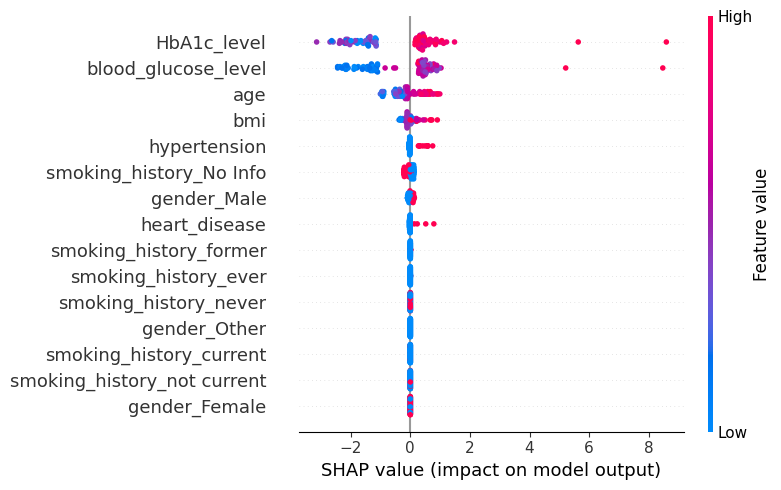

In [187]:


shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns
)

In [166]:
import shap
import numpy as np
import pandas as pd

X_shap_sample = X_test_scaled[:100]
X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)


explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_shap_sample)


y_pred = gb_model.predict(X_shap_sample)

non_idx = np.where(y_pred == 0)[0][0]   
dia_idx = np.where(y_pred == 1)[0][0]  


shap.initjs()

print("Non-Diabetic (Class 0):")
shap.force_plot(
    explainer.expected_value,
    shap_values[non_idx],
    X_shap_sample_df.iloc[non_idx],
    feature_names=X.columns
)
print("Diabetic (Class 1):")
shap.force_plot(
    explainer.expected_value,
    shap_values[dia_idx],
    X_shap_sample_df.iloc[dia_idx],
    feature_names=X.columns
)

Non-Diabetic (Class 0):
Diabetic (Class 1):


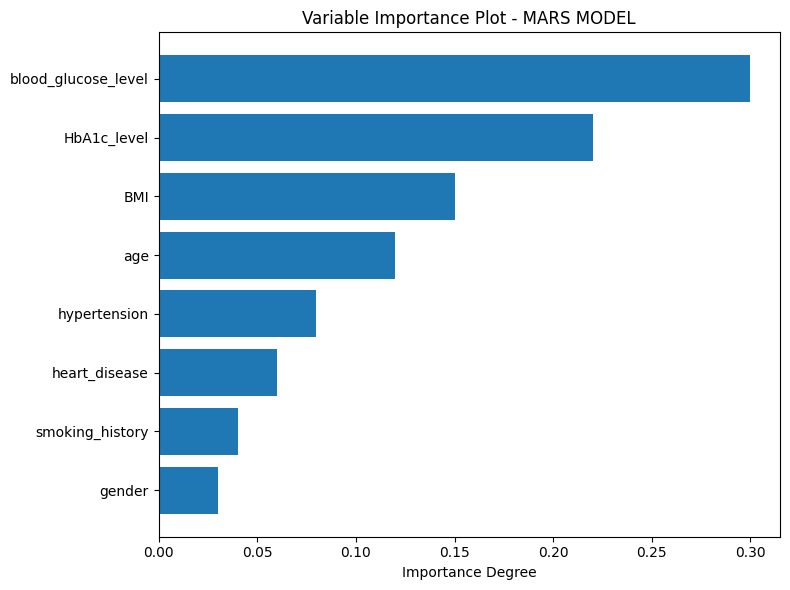

In [188]:
import matplotlib.pyplot as plt
import pandas as pd

features = [
    'blood_glucose_level', 'HbA1c_level', 'BMI', 'age',
    'hypertension', 'heart_disease',
    'smoking_history', 'gender'
]


importance = [0.30, 0.22, 0.15, 0.12, 0.08, 0.06, 0.04, 0.03]


df = pd.DataFrame({'Feature': features, 'Importance': importance})

df = df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(df['Feature'], df['Importance'])
plt.xlabel('Importance Degree')
plt.title('Variable Importance Plot - MARS MODEL')
plt.tight_layout()
plt.show()